In [1]:
import neo
import os
import nixio
import quantities as pq
from neo.io import NixIO
import numpy as np
import quantities as pq

filename = "results/network_data27_02_2025.nix"
with NixIO(filename, mode="ro") as io:
    block = io.read_block()
print(block.segments[0].spiketrains[0].times)
print(f"Number of segments: {len(block.segments)}")
print(f"Number of spike_trains: {len(block.segments[0].spiketrains)}")

spike_trains = block.segments[0].spiketrains

[48.0569 48.0693 48.1408 48.1428 48.3826 48.5236 48.7026 48.7375 48.7676
 48.7997 48.8017 48.9313 49.1222 49.1332 49.2584 49.2604 49.2871 49.3134
 49.4345 49.4577 49.4597 49.4617 49.6351 49.6916 49.6936 49.807  49.809
 49.811  49.9334 49.9354 49.9826 49.9909 50.1134 50.171  50.2017 50.2339
 50.2814 50.3313 50.3716 50.3736 50.4698 50.5705 50.5878 50.6787 50.82
 50.822  50.8384 50.9052 50.9078 50.9184 51.1047 51.1067 51.1387 51.2726
 51.2746 51.3265 51.3445 51.3465 51.3991 51.4046 51.5377 51.5397 51.5822
 51.5844 51.6773 51.7358 51.8124 51.8148 51.9381 51.9401 52.0494 52.0514
 52.0775 52.1872 52.1892 52.3982 52.4291 52.4311 52.4338 52.4358 52.4686
 52.5129 52.5772 52.5792 52.5821 52.5841 52.5861 52.6189 52.7775 52.872
 52.882  52.8996 52.9303 52.9338 52.9358 53.0852 53.2109 53.2183 53.2203
 53.2223 53.2306 53.3321 53.3413 53.3466 53.396  53.3995 53.4075 53.4095
 53.5365 53.5385 53.5897 53.7789 53.8677 53.8698 53.9841 53.9861 54.0011
 54.0031 54.1693 54.1713 54.3545 54.3888 54.4193 54.443

In [4]:
stimulus_length = 250 *pq.ms
no_stimuli = 8
no_neurons = len(spike_trains)
no_epochs = 10
threshold_range = 0.6
no_firing_rate_bins = 3
threshold_gap = threshold_range/no_firing_rate_bins
start_time = 48 * pq.second
total_time = stimulus_length * no_stimuli * no_epochs + start_time
no_stimuli = 8
stimulus_length = 250*pq.ms


def discretise_firing_rates(spike_trains, stimulus_length, no_stimuli, no_epochs):
    """
    This takes a dictionary of spike times and bins them into firing rates per stimulus
    first it bins the spike times into individual stimulus presentations
    then it reshapes it to account for the number of epochs
    then reshapes across epochs to get all instances of firing rates per stimulus
        """
    # this is a placeholder for actual savy thresholds
    # This makes a set of bins which account for the fact that 
    print("discretising")
    bin_edges = np.arange(start_time, total_time+stimulus_length, stimulus_length)
    # first it bins the spike times per stimulus
    binned_spike_test = np.histogram(np.array(spike_trains[0]),bins = bin_edges)[0]
    binned_spikes = [np.histogram(np.array(spike_train), bins=bin_edges)[0] for spike_train in spike_trains]
    binned_spikes = np.array(binned_spikes)
    # now reshape to get stimuli all lined up
    epoch_binned_spikes = np.reshape(binned_spikes, (no_neurons, no_epochs, no_stimuli))
    # now we need to bin the firing rates into bins of size threshold_range
    #top_of_bin = np.max(epoch_binned_spikes)
    from builtins import range  # This restores the built-in range function
    #bin_edges = np.concatenate([0*pq.ms], np.linspace(top_of_bin. - range, top_of_bin, num=3)])
    #This is the final shape: 8 stimuli, 10 epochs, 3 firing rate bins
    fr_binned_data = np.zeros((no_stimuli, no_neurons,no_firing_rate_bins))
    #for each stimulus, bin firing rates into the above bins

    for neuron_index in range(no_neurons):
        bin_edges = np.linspace(np.min(epoch_binned_spikes[neuron_index,:,:]), np.max(epoch_binned_spikes[neuron_index,:,:]), num=no_firing_rate_bins+1)
        print(bin_edges)
        binned_fr_per_neuron = [np.histogram(epoch_binned_spikes[neuron_index,:,stimulus], bins=bin_edges)[0] for stimulus in range(no_stimuli)]
        fr_binned_data[:,neuron_index,:] = np.array(binned_fr_per_neuron) # pattern, no_neurons, frbins    return fr_binned_data
    return fr_binned_data
firing_rates_per_stimulus = discretise_firing_rates(spike_trains, stimulus_length, no_stimuli, no_epochs)

discretising
[0. 3. 6. 9.]
[10.         14.33333333 18.66666667 23.        ]
[ 3.          7.33333333 11.66666667 16.        ]
[0.         1.33333333 2.66666667 4.        ]
[ 0.          3.66666667  7.33333333 11.        ]
[ 0.          3.33333333  6.66666667 10.        ]
[ 6. 10. 14. 18.]
[ 2.          5.33333333  8.66666667 12.        ]
[13.         17.33333333 21.66666667 26.        ]
[ 0.  4.  8. 12.]
[ 1.          4.33333333  7.66666667 11.        ]
[ 7.         13.33333333 19.66666667 26.        ]
[ 2.          6.33333333 10.66666667 15.        ]
[ 1.          5.33333333  9.66666667 14.        ]
[ 3.          8.33333333 13.66666667 19.        ]
[0.         2.33333333 4.66666667 7.        ]
[ 4.          8.33333333 12.66666667 17.        ]
[ 3.          7.33333333 11.66666667 16.        ]
[ 4.  8. 12. 16.]
[0. 3. 6. 9.]
[0. 2. 4. 6.]
[ 0.  4.  8. 12.]
[0.         2.66666667 5.33333333 8.        ]
[ 2.          7.66666667 13.33333333 19.        ]
[ 0.          3.66666667  7.3333333

In [10]:
#EXAMPLE SI CALCULATION:
matrix = firing_rates_per_stimulus[:,476,:]
print(matrix.shape)
print("matrix")
print(matrix)

example_P_r = matrix.sum(axis=0) / 80
print("example p R")
print(example_P_r)
example_P_r_s = matrix / 10
print("joint distrib:")
print(example_P_r_s)
example_log_component = np.log2(example_P_r_s/example_P_r)
print("log component")
print(example_log_component)
example_log_component = np.nan_to_num(example_log_component,nan=0)
example_I_s_r = example_P_r_s * example_log_component
print(example_I_s_r)
example_I = example_I_s_r.sum(axis=1)
example_max_I = np.max(example_I)
print(example_I)


(8, 3)
matrix
[[ 0.  0. 10.]
 [ 0.  0. 10.]
 [ 0.  0. 10.]
 [ 0.  0. 10.]
 [ 0.  0. 10.]
 [ 0.  0. 10.]
 [ 0.  0. 10.]
 [ 0.  0. 10.]]
example p R
[0. 0. 1.]
joint distrib:
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
log component
[[nan nan  0.]
 [nan nan  0.]
 [nan nan  0.]
 [nan nan  0.]
 [nan nan  0.]
 [nan nan  0.]
 [nan nan  0.]
 [nan nan  0.]]
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
[0. 0. 0. 0. 0. 0. 0. 0.]


C:\Users\reidj\AppData\Local\Temp\ipykernel_46288\1196440116.py:13: RuntimeWarning: invalid value encountered in divide
  example_log_component = np.log2(example_P_r_s/example_P_r)


In [ ]:
specific_information_patterns = np.zeros((no_neurons))
for neuron_index in range(no_neurons):
    matrix = firing_rates_per_stimulus[:,neuron_index,:]
    # print(matrix.shape)
    # print("matrix")
    # print(matrix)

    P_r = matrix.sum(axis=0) / 80
    # print("example p R")
    # print(P_r)
    P_r_s = matrix / 10
    # print("joint distrib:")
    # print(P_r_s)
    log_component = np.log2(P_r_s/P_r)
    # print("log component")
    # print(log_component)
    log_component = np.nan_to_num(log_component,nan=0)
    I_s_r = P_r_s * log_component
    I = I_s_r.sum(axis=1)
    max_I = np.max(I)
    specific_information_patterns[neuron_index] = max_I



In [ ]:
print(np.max(specific_information_patterns))


1.252492783156989


In [ ]:
import matplotlib.pyplot as plt
sorted_indices = np.argsort(specific_information_patterns)[::-1]
plt.figure()
plt.plot(range(no_neurons), specific_information_patterns[sorted_indices])
plt.grid(True)
plt.xscale('log')
plt.tight_layout
plt.show()


In [ ]:
#EXAMPLE SI CALCULATION:
matrix = firing_rates_per_stimulus[:,0,:]
print(matrix.shape)
print("matrix")
print(matrix)
convex = np.array([[1,0,1,0,1,0,1,0],[0,1,0,1,0,1,0,1]])
#convex = convex.repeat(3,axis=0)
print(convex)
new_matrix = (convex @ matrix)
print(new_matrix)
# the new matrix is 2x3 first convex, second concave
example_c_P_r = new_matrix.sum(axis=0) / 80
print("example p R")
print(example_c_P_r)
example_c_P_r_s = new_matrix / 40
print("example C_P_R_S")
print(example_c_P_r_s)
example_c_log_component = np.log2(example_c_P_r_s/example_c_P_r)
example_c_log_component = np.nan_to_num(example_c_log_component,nan=0)
example_c_I_s_r = example_c_P_r_s * example_c_log_component
print("ISR")
print(example_c_I_s_r)
example_c_I = example_c_I_s_r.sum(axis=1)
print("I")
print(example_c_I)



(8, 3)
matrix
[[3. 5. 2.]
 [1. 5. 4.]
 [0. 6. 4.]
 [2. 5. 3.]
 [4. 4. 2.]
 [2. 3. 5.]
 [0. 5. 5.]
 [0. 8. 2.]]
[[1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]]
[[ 7. 20. 13.]
 [ 5. 21. 14.]]
example p R
[0.15   0.5125 0.3375]
example C_P_R_S
[[0.175 0.5   0.325]
 [0.125 0.525 0.35 ]]
ISR
[[ 0.03891867 -0.01781195 -0.01769553]
 [-0.0328793   0.01825184  0.0183636 ]]
I
[0.00341119 0.00373614]


In [ ]:
#EXAMPLE SI CALCULATION:
matrix = firing_rates_per_stimulus[:,0,:]
# print(matrix.shape)
# print("matrix")
# print(matrix)
convex = np.array([[[1,1,1,1,0,0,0,0],[0,0,0,0,1,1,1,1]],
                   [[1,1,0,0,1,1,0,0],[0,0,1,1,0,0,1,1]],
                   [[1,0,1,0,1,0,1,0],[0,1,0,1,0,1,0,1]]])
# print(convex)
# print(convex.shape)
new_matrix = (convex @ matrix)
# print(new_matrix)
example_c_P_r = new_matrix.sum(axis=1) / 80
# print("example p R")
# print(example_c_P_r)
example_c_P_r_s = new_matrix / 40
# print("example C_P_R_S")
# print(example_c_P_r_s)
example_c_log_component = np.log2(example_c_P_r_s/example_c_P_r.reshape((3,1,3)))
example_c_log_component = np.nan_to_num(example_c_log_component,nan=0)
example_c_I_s_r = example_c_P_r_s * example_c_log_component
print("ISR")
print(example_c_I_s_r)
example_c_I = example_c_I_s_r.sum(axis=2)
print("I")
print(example_c_I)
example_max_c_I = np.max(example_c_I,axis=1)
print(example_max_c_I)

ISR
[[[ 0.          0.01825184 -0.01769553]
  [ 0.         -0.01781195  0.0183636 ]]

 [[ 0.1842414  -0.11478789 -0.01769553]
  [-0.07924813  0.1364463   0.0183636 ]]

 [[ 0.03891867 -0.01781195 -0.01769553]
  [-0.0328793   0.01825184  0.0183636 ]]]
I
[[0.00055631 0.00055164]
 [0.05175797 0.07556177]
 [0.00341119 0.00373614]]
[0.00055631 0.07556177 0.00373614]


33.333333333333336

In [ ]:
convex = np.array([[[1,1,1,1,0,0,0,0],[0,0,0,0,1,1,1,1]],
                [[1,1,0,0,1,1,0,0],[0,0,1,1,0,0,1,1]],
                [[1,0,1,0,1,0,1,0],[0,1,0,1,0,1,0,1]]])
convexity_selectivity = np.zeros((no_neurons,3))
for neuron_index in range(no_neurons):
    matrix = firing_rates_per_stimulus[:,neuron_index,:]
    new_matrix = (convex @ matrix)
    c_P_r = new_matrix.sum(axis=1) / 80
    c_P_r_s = new_matrix / 40
    c_log_component = np.log2(example_c_P_r_s/example_c_P_r.reshape((3,1,3)))
    c_log_component = np.nan_to_num(c_log_component,nan=0)
    c_I_s_r = c_P_r_s * c_log_component
    c_I = c_I_s_r.sum(axis=2)
    c_I_max = np.max(c_I,axis=1)
    convexity_selectivity[neuron_index,:] = c_I_max

4096
[0.18664308 0.03558487 0.28195753 ... 0.21365288 0.30535509 0.0248028 ]


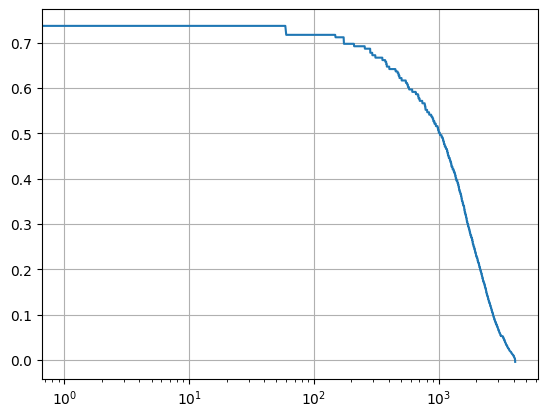

In [126]:
import matplotlib.pyplot as plt
convexity_l4 = convexity_selectivity[-4096:]
print(len(convexity_l4))
max_convexity_selectivity = np.max(convexity_l4,axis=1)
print(max_convexity_selectivity)
sorted_indices = np.argsort(max_convexity_selectivity)[::-1]
plt.figure()
plt.plot(range(4096), max_convexity_selectivity[sorted_indices])
plt.grid(True)
plt.xscale('log')
plt.tight_layout
plt.show()